
# How an MD Simulation Actually Runs: Velocities, Forces, and Integration
### A hands-on look at Newton's equations, Maxwell-Boltzmann velocities, temperature and pressure

This notebook focuses on *describing* basic properties like **temperature and pressure**.

We deliberately use the simplest possible system: a box of identical, uncharged, non-bonded particles interacting only through a **Lennard-Jones potential** — think of it as a toy model for liquid argon.



## 0. Setup


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

import openmm as mm
from openmm import app, unit
import py3Dmol

SEED = 7
rng = np.random.default_rng(SEED)

print("OpenMM version:", mm.version.version)


OpenMM version: 8.6.0.dev-c6173db



## 1. The physical model: the Lennard-Jones potential

Any two atoms that are not chemically bonded still interact: they weakly attract each other at moderate distances (van der Waals / London dispersion forces) and strongly repel each other when pushed too close together (their electron clouds cannot overlap). The **Lennard-Jones (LJ) potential** is the standard, simple mathematical model for this:

$$ U(r) = 4\varepsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6} \right] $$


where $r$ is the distance between the two particles, $\varepsilon$ sets the depth of the attractive well (how strongly they like to stick together), and $\sigma$ sets the effective particle size (roughly, the distance at which the potential crosses zero). The $r^{-12}$ term dominates at short range (steep repulsion), and the $r^{-6}$ term dominates at longer range (attraction).

<img src="images/van_der_Waals_graph.gif" width="300">

We will use standard textbook parameters for **liquid argon** — a real substance whose behavior is very well described by a pure LJ potential.


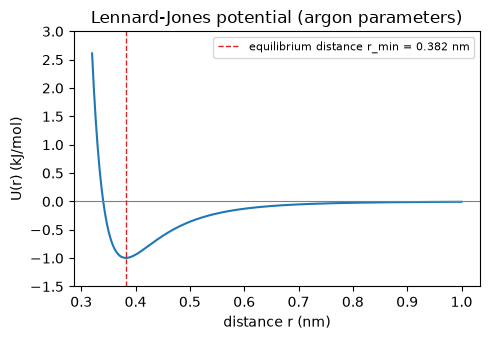

sigma = 0.3405 nm, epsilon = 0.996 kJ/mol
Minimum at r = 0.3822 nm, U(r_min) = -0.996 kJ/mol


In [3]:
# Standard Lennard-Jones parameters for argon (textbook values)
sigma = 0.3405 * unit.nanometer        # effective particle diameter
epsilon = 0.996 * unit.kilojoule_per_mole   # depth of the attractive well
particle_mass = 39.948 * unit.amu      # atomic mass of argon

sigma_nm = sigma.value_in_unit(unit.nanometer)
epsilon_kjmol = epsilon.value_in_unit(unit.kilojoule_per_mole)

def lj_potential(r_nm):
    sr6 = (sigma_nm / r_nm) ** 6
    sr12 = sr6 ** 2
    return 4 * epsilon_kjmol * (sr12 - sr6)

r_vals = np.linspace(0.32, 1.0, 400)
U_vals = lj_potential(r_vals)
r_min = 2 ** (1 / 6) * sigma_nm  # distance at the minimum of the well

plt.figure(figsize=(5, 3.5))
plt.plot(r_vals, U_vals)
plt.axhline(0, color="gray", lw=0.8)
plt.axvline(r_min, color="tab:red", ls="--", lw=1, label=f"equilibrium distance r_min = {r_min:.3f} nm")
plt.ylim(-1.5, 3)
plt.xlabel("distance r (nm)")
plt.ylabel("U(r) (kJ/mol)")
plt.title("Lennard-Jones potential (argon parameters)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"sigma = {sigma_nm:.4f} nm, epsilon = {epsilon_kjmol:.3f} kJ/mol")
print(f"Minimum at r = {r_min:.4f} nm, U(r_min) = {lj_potential(r_min):.3f} kJ/mol")



Notice: for $r$ smaller than about $\sigma$, the potential shoots up almost vertically (very strong repulsion — this is what keeps atoms from overlapping). For $r$ larger than $r_{min}$, the potential rises slowly back toward zero (weak attraction that fades with distance). The **force** on a particle is simply the negative slope of this curve, $F(r) = -dU/dr$: positive (repulsive, pushing particles apart) at short range, negative (attractive, pulling them together) at longer range.



## 2. Building the initial configuration

We place $N=125$ particles on a simple cubic lattice ($5\times5\times5$), spaced a bit further apart than the LJ equilibrium distance so that the starting configuration is not artificially compressed. 


In [4]:
N_SIDE = 5
N = N_SIDE ** 3                       # 125 particles
SPACING = 1.2 * sigma_nm              # nm, a bit looser than the LJ minimum
BOX_LENGTH = N_SIDE * SPACING         # cubic box, nm

topology = app.Topology()
chain = topology.addChain()
positions_list = []
for ix in range(N_SIDE):
    for iy in range(N_SIDE):
        for iz in range(N_SIDE):
            residue = topology.addResidue("AR", chain)
            topology.addAtom("Ar", app.element.argon, residue)
            positions_list.append([ix * SPACING, iy * SPACING, iz * SPACING])

positions = np.array(positions_list)
box_vectors = np.array([[BOX_LENGTH, 0, 0], [0, BOX_LENGTH, 0], [0, 0, BOX_LENGTH]])
topology.setPeriodicBoxVectors(box_vectors.tolist())

number_density = N / np.linalg.det(box_vectors)  # particles / nm^3
print(f"N = {N} particles, cubic box of side {BOX_LENGTH:.3f} nm")
print(f"Number density: {number_density:.2f} particles/nm^3")


N = 125 particles, cubic box of side 2.043 nm
Number density: 14.66 particles/nm^3


In [5]:
# Reusable visualization helper (same fix as in the ethanol notebook:
# addBox needs ONE combined dict with geometry + style, or the wireframe is ignored
# and you get an opaque box hiding everything inside).
def render_particles(topology, positions_nm, box_vectors, title=None, width=450, height=400):
    pdb_path = "_frame_lj.pdb"
    with open(pdb_path, "w") as f:
        app.PDBFile.writeFile(topology, positions_nm * unit.nanometer, f)

    view = py3Dmol.view(width=width, height=height)
    view.addModel(open(pdb_path).read(), "pdb")
    view.setStyle({"sphere": {"scale": 0.35, "color": "orange"}})

    cx, cy, cz = box_vectors[0][0] / 2, box_vectors[1][1] / 2, box_vectors[2][2] / 2
    view.addBox({
        "center": {"x": cx * 10, "y": cy * 10, "z": cz * 10},
        "dimensions": {"w": box_vectors[0][0] * 10, "h": box_vectors[1][1] * 10, "d": box_vectors[2][2] * 10},
        "wireframe": True,
        "linewidth": 1.5,
        "color": "black",
    })
    view.zoomTo()
    if title:
        print(title)
    view.show()

def positions_from_state(simulation):
    """Wrapped (inside the primary box) positions, as a plain NumPy array in nm."""
    state = simulation.context.getState(getPositions=True, enforcePeriodicBox=True)
    return state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)

def current_box_vectors(simulation):
    vecs = simulation.context.getState().getPeriodicBoxVectors(asNumpy=True).value_in_unit(unit.nanometer)
    return np.array(vecs)

render_particles(topology, positions, box_vectors, title="Initial configuration: 125 argon-like particles on a lattice")


Initial configuration: 125 argon-like particles on a lattice


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


## 3. Assigning initial velocities: the Maxwell-Boltzmann distribution

A structure with zero velocity has no temperature. **Temperature is, microscopically, a statement about how fast particles are moving on average.** The equipartition theorem tells us that, at thermal equilibrium at temperature $T$, each independent direction of motion (each *degree of freedom*) carries, on average, kinetic energy $\tfrac12 k_B T$:

$$ \left\langle \tfrac{1}{2} m v_x^2 \right\rangle = \tfrac{1}{2} k_B T $$

and the same for $v_y$ and $v_z$. This means each velocity **component** ($v_x$, $v_y$, or $v_z$, separately, for every particle) should be drawn from a Gaussian (normal) distribution centered at zero, with standard deviation $\sqrt{k_B T / m}$. These independent Gaussian components represent the **Maxwell-Boltzmann distribution**, expressed in Cartesian components. Its more familiar form is obtained by computing $|\vec v| = \sqrt{v_x^2+v_y^2+v_z^2}$ from these same Gaussian components.


In [6]:
TARGET_TEMPERATURE = 100 * unit.kelvin   # a cold, dense, liquid-like state for argon

R_gas = unit.MOLAR_GAS_CONSTANT_R.value_in_unit(unit.kilojoule_per_mole / unit.kelvin)  # kJ/mol/K
mass_amu = particle_mass.value_in_unit(unit.amu)
T_target_K = TARGET_TEMPERATURE.value_in_unit(unit.kelvin)

# Standard deviation of each velocity COMPONENT, from equipartition: sigma_v = sqrt(kT/m)
# NOTE ON UNITS: OpenMM's unit system (nm, ps, amu, kJ/mol) is built so that
# kJ/mol divided by amu gives nm^2/ps^2 directly, with NO extra conversion factor
# -- so we can safely mix these numbers in plain NumPy below.
sigma_v = np.sqrt(R_gas * T_target_K / mass_amu)   # nm/ps
print(f"Standard deviation per velocity component at {T_target_K:.0f} K: {sigma_v:.4f} nm/ps")

velocities = rng.normal(loc=0.0, scale=sigma_v, size=(N, 3))   # nm/ps


Standard deviation per velocity component at 100 K: 0.1443 nm/ps


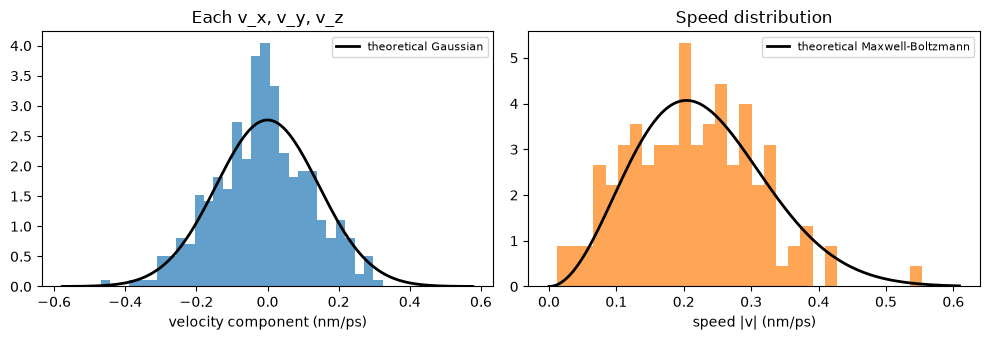

In [7]:
# Sanity check: do the individual velocity components look Gaussian,
# and does the SPEED distribution (|v|) look like the textbook Maxwell-Boltzmann curve?
speeds = np.linalg.norm(velocities, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(velocities.flatten(), bins=30, density=True, alpha=0.7, color="tab:blue")
v_axis = np.linspace(-4*sigma_v, 4*sigma_v, 200)
gaussian = (1/(sigma_v*np.sqrt(2*np.pi))) * np.exp(-v_axis**2/(2*sigma_v**2))
axes[0].plot(v_axis, gaussian, color="k", lw=2, label="theoretical Gaussian")
axes[0].set_xlabel("velocity component (nm/ps)"); axes[0].set_title("Each v_x, v_y, v_z"); axes[0].legend(fontsize=8)

axes[1].hist(speeds, bins=30, density=True, alpha=0.7, color="tab:orange")
s_axis = np.linspace(0, speeds.max()*1.1, 200)
# Maxwell-Boltzmann SPEED distribution (3D), derived from 3 independent Gaussian components
mb_speed = (4*np.pi*s_axis**2) * (1/(2*np.pi*sigma_v**2))**1.5 * np.exp(-s_axis**2/(2*sigma_v**2))
axes[1].plot(s_axis, mb_speed, color="k", lw=2, label="theoretical Maxwell-Boltzmann")
axes[1].set_xlabel("speed |v| (nm/ps)"); axes[1].set_title("Speed distribution"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()



Two practical corrections are always applied before starting a simulation:

1. **Remove the center-of-mass (COM) velocity.** Random sampling almost never gives an exact zero net momentum, which means the *whole box* would slowly drift sideways. That drift doesn't correspond to any physical heating and would corrupt our temperature measurement, so we subtract it off.
2. **Rescale to hit the target temperature exactly.** Even after removing the COM drift, a finite, random sample of velocities essentially never gives *exactly* the target temperature (only approximately) — this is a real, physical effect (finite-size statistical fluctuations), not a bug, and we will meet it again once the simulation is running. For a clean starting point, we rescale all velocities by a common factor so the *initial* instantaneous temperature matches our target precisely. (This rescaling trick is, in fact, the core idea behind the simplest possible thermostat!)


In [8]:
def degrees_of_freedom(n_particles, n_constraints=0, remove_com=True):
    ndof = 3 * n_particles - n_constraints
    if remove_com:
        ndof -= 3
    return ndof

def temperature_from_velocities(vel_nm_ps, mass_amu, ndof):
    ke = 0.5 * mass_amu * np.sum(vel_nm_ps ** 2)   # kJ/mol (unit-consistent, see note above)
    return 2 * ke / (ndof * R_gas)

ndof = degrees_of_freedom(N, n_constraints=0, remove_com=True)

velocities -= velocities.mean(axis=0)                       # 1. remove COM velocity
T_before_rescale = temperature_from_velocities(velocities, mass_amu, ndof)
velocities *= np.sqrt(T_target_K / T_before_rescale)         # 2. rescale to hit target exactly
T_after_rescale = temperature_from_velocities(velocities, mass_amu, ndof)

print(f"Degrees of freedom: {ndof} (3N = {3*N}, minus 3 for the removed COM motion)")
print(f"Instantaneous T right after random sampling: {T_before_rescale:.2f} K")
print(f"Instantaneous T after removing COM drift and rescaling: {T_after_rescale:.2f} K (target: {T_target_K:.0f} K)")


Degrees of freedom: 372 (3N = 375, minus 3 for the removed COM motion)
Instantaneous T right after random sampling: 85.18 K
Instantaneous T after removing COM drift and rescaling: 100.00 K (target: 100 K)



## 4. Newton's equations of motion and the Velocity Verlet algorithm

We now have positions and velocities. The physics that tells us how they change in time is just **Newton's second law**, applied to every particle $i$:

$$ \vec{a}_i(t) = \frac{\vec{F}_i(t)}{m_i}, \qquad \vec{F}_i(t) = -\nabla_i U(\{\vec r\}) $$

The force on each particle is (minus) the slope of the total potential energy with respect to that particle's position — for our LJ system, it is simply the sum of the pairwise LJ forces from every other particle.

The tricky part is *numerically* integrating this over time. The simplest idea you might think of — "Euler's method" — updates position and velocity using only information available at the *current* time:

$$ x(t+\Delta t) = x(t) + v(t)\Delta t, \qquad v(t+\Delta t) = v(t) + a(t)\Delta t $$

This turns out to work poorly for MD: small numerical errors accumulate every step and the total energy of the system drifts away, usually growing without bound. Essentially all MD codes (including OpenMM) instead use the **Velocity Verlet** algorithm:

$$ x(t+\Delta t) = x(t) + v(t)\Delta t + \tfrac12 a(t)\Delta t^2 $$
$$ \text{(recompute forces/accelerations at the new positions)} $$
$$ v(t+\Delta t) = v(t) + \tfrac12\big[a(t) + a(t+\Delta t)\big]\Delta t $$

The key difference: the velocity update uses the **average** of the old and new acceleration, not just the old one. This small change makes Velocity Verlet *time-reversible* and (for the physics involved here) *symplectic* — properties that keep the total energy oscillating around a constant value indefinitely, instead of drifting away.

Let's see this difference directly, with a tiny, fully transparent example: **two** particles in **one dimension**, interacting only through the LJ potential, started at rest, slightly pulled apart from the equilibrium distance.

<img src="images/trajectory_sim.jpg" width="400">


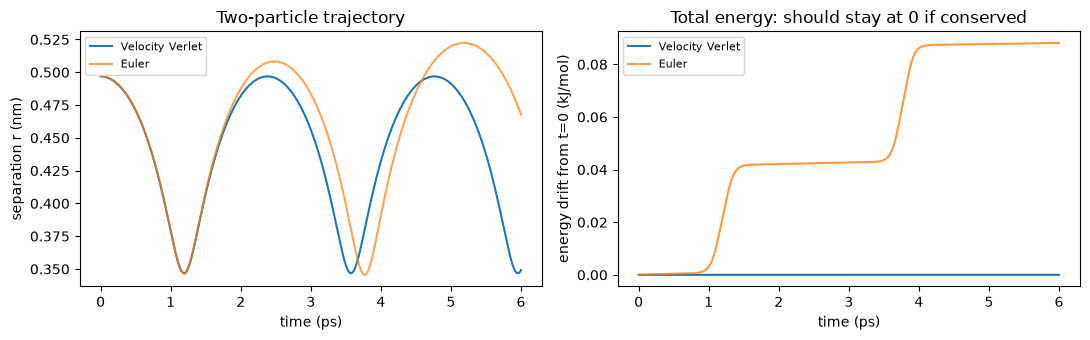

Velocity Verlet max energy drift: 1.99e-05 kJ/mol
Euler max energy drift:           8.82e-02 kJ/mol


In [9]:
def lj_force_1d(r):
    """F(r) = -dU/dr. Positive = repulsive (pushes the two particles apart)."""
    sr6 = (sigma_nm / r) ** 6
    sr12 = sr6 ** 2
    return 24 * epsilon_kjmol * (2 * sr12 - sr6) / r

r_eq = 2 ** (1 / 6) * sigma_nm
x1_0, x2_0 = 0.0, 1.3 * r_eq   # start stretched out, at rest
v1_0, v2_0 = 0.0, 0.0

def total_energy(x1, x2, v1, v2, m):
    KE = 0.5 * m * (v1 ** 2 + v2 ** 2)
    PE = lj_potential(x2 - x1)
    return KE + PE

def run_velocity_verlet(dt, n_steps, m=mass_amu):
    x1, x2, v1, v2 = x1_0, x2_0, v1_0, v2_0
    F = lj_force_1d(x2 - x1)          # force ON particle 2 FROM particle 1 (Newton's 3rd law: opposite on 1)
    a1, a2 = -F / m, F / m
    sep_hist, energy_hist = [x2 - x1], [total_energy(x1, x2, v1, v2, m)]
    for _ in range(n_steps):
        x1 += v1 * dt + 0.5 * a1 * dt ** 2
        x2 += v2 * dt + 0.5 * a2 * dt ** 2
        F_new = lj_force_1d(x2 - x1)
        a1_new, a2_new = -F_new / m, F_new / m
        v1 += 0.5 * (a1 + a1_new) * dt
        v2 += 0.5 * (a2 + a2_new) * dt
        a1, a2 = a1_new, a2_new
        sep_hist.append(x2 - x1)
        energy_hist.append(total_energy(x1, x2, v1, v2, m))
    return np.array(sep_hist), np.array(energy_hist)

def run_euler(dt, n_steps, m=mass_amu):
    x1, x2, v1, v2 = x1_0, x2_0, v1_0, v2_0
    sep_hist, energy_hist = [x2 - x1], [total_energy(x1, x2, v1, v2, m)]
    for _ in range(n_steps):
        F = lj_force_1d(x2 - x1)
        a1, a2 = -F / m, F / m
        x1, x2, v1, v2 = x1 + v1 * dt, x2 + v2 * dt, v1 + a1 * dt, v2 + a2 * dt
        sep_hist.append(x2 - x1)
        energy_hist.append(total_energy(x1, x2, v1, v2, m))
    return np.array(sep_hist), np.array(energy_hist)

DT_DEMO = 0.002   # ps
N_STEPS_DEMO = 3000
sep_verlet, energy_verlet = run_velocity_verlet(DT_DEMO, N_STEPS_DEMO)
sep_euler, energy_euler = run_euler(DT_DEMO, N_STEPS_DEMO)
time_axis = np.arange(N_STEPS_DEMO + 1) * DT_DEMO

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(time_axis, sep_verlet, label="Velocity Verlet")
axes[0].plot(time_axis, sep_euler, label="Euler", alpha=0.7)
axes[0].set_xlabel("time (ps)"); axes[0].set_ylabel("separation r (nm)"); axes[0].set_title("Two-particle trajectory")
axes[0].legend(fontsize=8)

axes[1].plot(time_axis, energy_verlet - energy_verlet[0], label="Velocity Verlet")
axes[1].plot(time_axis, energy_euler - energy_euler[0], label="Euler", alpha=0.8)
axes[1].set_xlabel("time (ps)"); axes[1].set_ylabel("energy drift from t=0 (kJ/mol)")
axes[1].set_title("Total energy: should stay at 0 if conserved")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Velocity Verlet max energy drift: {np.max(np.abs(energy_verlet - energy_verlet[0])):.2e} kJ/mol")
print(f"Euler max energy drift:           {np.max(np.abs(energy_euler - energy_euler[0])):.2e} kJ/mol")



The two-body trajectory itself looks similar for a while, but the **energy** tells the real story: Velocity Verlet keeps the total energy essentially fixed (only tiny numerical noise), while plain Euler leaks energy steadily, growing worse the longer you run.



## 5. Scaling up: the same algorithm, hundreds of particles, done by OpenMM

We now hand our 125-particle system to OpenMM and use a plain `VerletIntegrator` — the constant-**energy** (NVE) ensemble, with **no thermostat at all**. If OpenMM's Velocity Verlet implementation is doing exactly what we just did by hand (just for many particles and many pairwise interactions instead of one pair), the total energy should stay essentially constant over the whole run. This is the standard way of "unit testing" that a simulation setup is sane, before trusting any of its results.


In [10]:
def build_lj_system(topology, box_vectors):
    n_particles = topology.getNumAtoms()
    box_length = box_vectors[0][0]
    system = mm.System()
    for _ in range(n_particles):
        system.addParticle(particle_mass)
    system.setDefaultPeriodicBoxVectors(*[mm.Vec3(*row) for row in box_vectors])

    nonbonded = mm.NonbondedForce()
    nonbonded.setNonbondedMethod(mm.NonbondedForce.CutoffPeriodic)
    nonbonded.setCutoffDistance(min(1.0, box_length / 2 - 0.01) * unit.nanometer)
    nonbonded.setUseDispersionCorrection(True)
    for _ in range(n_particles):
        nonbonded.addParticle(0.0, sigma, epsilon)   # charge=0: purely van der Waals, no electrostatics
    system.addForce(nonbonded)
    system.addForce(mm.CMMotionRemover())
    return system

system_nve = build_lj_system(topology, box_vectors)

integrator_nve = mm.VerletIntegrator(0.001 * unit.picoseconds)   # plain Verlet: NO thermostat, NO barostat
platform = mm.Platform.getPlatformByName("CPU")
simulation_nve = app.Simulation(topology, system_nve, integrator_nve, platform, {"Threads": "4"})
simulation_nve.context.setPositions(positions * unit.nanometer)
simulation_nve.context.setVelocities(velocities * unit.nanometer / unit.picosecond)

state = simulation_nve.context.getState(getEnergy=True)
print(f"Initial potential energy: {state.getPotentialEnergy()}")
print(f"Initial kinetic energy:   {state.getKineticEnergy()}")


Initial potential energy: -524.5860430809861 kJ/mol
Initial kinetic energy:   154.64900469702775 kJ/mol


NVE run (8000 steps) finished in 0.7 s


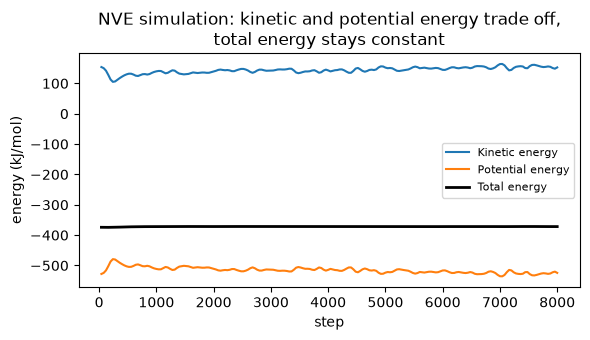

Total energy: mean = -371.78 kJ/mol, drift (max-min) = 2.964 kJ/mol (0.797 % of the total)


In [11]:
N_STEPS_NVE = 8000
RECORD_EVERY = 40

steps_nve, KE_nve, PE_nve = [], [], []
t0 = time.time()
for i in range(N_STEPS_NVE // RECORD_EVERY):
    simulation_nve.step(RECORD_EVERY)
    state = simulation_nve.context.getState(getEnergy=True)
    steps_nve.append((i + 1) * RECORD_EVERY)
    KE_nve.append(state.getKineticEnergy().value_in_unit(unit.kilojoule_per_mole))
    PE_nve.append(state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole))
print(f"NVE run ({N_STEPS_NVE} steps) finished in {time.time() - t0:.1f} s")

KE_nve, PE_nve = np.array(KE_nve), np.array(PE_nve)
E_total_nve = KE_nve + PE_nve

plt.figure(figsize=(6, 3.5))
plt.plot(steps_nve, KE_nve, label="Kinetic energy")
plt.plot(steps_nve, PE_nve, label="Potential energy")
plt.plot(steps_nve, E_total_nve, label="Total energy", color="k", lw=2)
plt.xlabel("step"); plt.ylabel("energy (kJ/mol)")
plt.title("NVE simulation: kinetic and potential energy trade off,\ntotal energy stays constant")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Total energy: mean = {E_total_nve.mean():.2f} kJ/mol, "
      f"drift (max-min) = {E_total_nve.max() - E_total_nve.min():.3f} kJ/mol "
      f"({100*(E_total_nve.max()-E_total_nve.min())/abs(E_total_nve.mean()):.3f} % of the total)")


In [12]:
render_particles(topology, positions_from_state(simulation_nve), current_box_vectors(simulation_nve),
                  title="System after the NVE run (particles have rearranged; box size unchanged)")


System after the NVE run (particles have rearranged; box size unchanged)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Look at the kinetic and potential energy curves: they clearly **oscillate in opposite directions** — whenever particles speed up (KE rises), it's because they moved to a more favorable, lower-energy arrangement (PE drops), and vice versa. This back-and-forth exchange between kinetic and potential energy is the whole content of Newton's second law played out over time. Their **sum**, the total energy, stays essentially flat — our confirmation that the simulation is physically correct.



## 6. Where do temperature and pressure actually come from?

Neither temperature nor pressure is a fundamental input to the simulation. Both are **derived, statistical quantities**, computed from the instantaneous positions and velocities.

**Temperature**, again from equipartition, rearranged to solve for $T$ instead of the velocities:

$$ T = \frac{2\, \text{KE}}{n_{\text{dof}}\, k_B} $$

where $\text{KE} = \sum_i \tfrac12 m_i v_i^2$ is computed directly from the current velocities, and $n_{\text{dof}}$ is the number of degrees of freedom (here: $3N - 3$, since we removed the 3 center-of-mass degrees of freedom; in the ethanol notebook, bond constraints removed additional degrees of freedom too).

**Pressure** is less obvious. Intuitively, pressure comes from particles colliding with each other (and, in a real experiment, with the container walls) and exchanging momentum. Under periodic boundary conditions there are no walls, so we use the equivalent, exact microscopic expression from the **virial theorem**:

$$ P = \frac{2\,\text{KE} + W}{3V}, \qquad W = \sum_i \vec r_i \cdot \vec F_i $$

$W$ is called the **virial**: for every particle, take the dot product of its position with the total force acting on it, and sum over all particles. (This looks like it should depend on where you put the origin of your coordinate system — but because the *net* force on the whole system is always zero, $W$ turns out to be origin-independent, which is what makes this formula meaningful.) The first term, $2\,\text{KE}$, is the "kinetic" contribution to pressure (particles carrying momentum); $W$ is the "interaction" contribution (particles pushing on each other).

Both formulas need nothing beyond what the simulation already computes at every step: positions, velocities, and forces.


In [13]:
def temperature_kelvin(state, n_dof):
    return (2 * state.getKineticEnergy() / (n_dof * unit.MOLAR_GAS_CONSTANT_R)).value_in_unit(unit.kelvin)

def pressure_bar(simulation):
    state = simulation.context.getState(getEnergy=True, getForces=True, getPositions=True)
    r = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    f = state.getForces(asNumpy=True).value_in_unit(unit.kilojoule_per_mole / unit.nanometer)
    ke = state.getKineticEnergy().value_in_unit(unit.kilojoule_per_mole)
    box = state.getPeriodicBoxVectors(asNumpy=True).value_in_unit(unit.nanometer)
    V = np.linalg.det(box)
    virial = np.sum(r * f)
    P_kJ_mol_nm3 = (2 * ke + virial) / (3 * V)
    return P_kJ_mol_nm3 * 16.6054   # kJ/mol/nm^3 -> bar

ndof_system = degrees_of_freedom(N, n_constraints=0, remove_com=True)

# Cross-check: manual KE from raw velocities vs. OpenMM's own KE for the same state
state = simulation_nve.context.getState(getEnergy=True, getVelocities=True)
vel_now = state.getVelocities(asNumpy=True).value_in_unit(unit.nanometer / unit.picosecond)
KE_manual = 0.5 * mass_amu * np.sum(vel_now ** 2)
KE_openmm = state.getKineticEnergy().value_in_unit(unit.kilojoule_per_mole)
print(f"KE computed by hand from velocities: {KE_manual:.3f} kJ/mol")
print(f"KE reported by OpenMM's State:       {KE_openmm:.3f} kJ/mol")
print(f"Instantaneous temperature: {temperature_kelvin(state, ndof_system):.1f} K")
print(f"Instantaneous pressure:    {pressure_bar(simulation_nve):.1f} bar")


KE computed by hand from velocities: 152.419 kJ/mol
KE reported by OpenMM's State:       152.495 kJ/mol
Instantaneous temperature: 98.6 K
Instantaneous pressure:    -487.0 bar


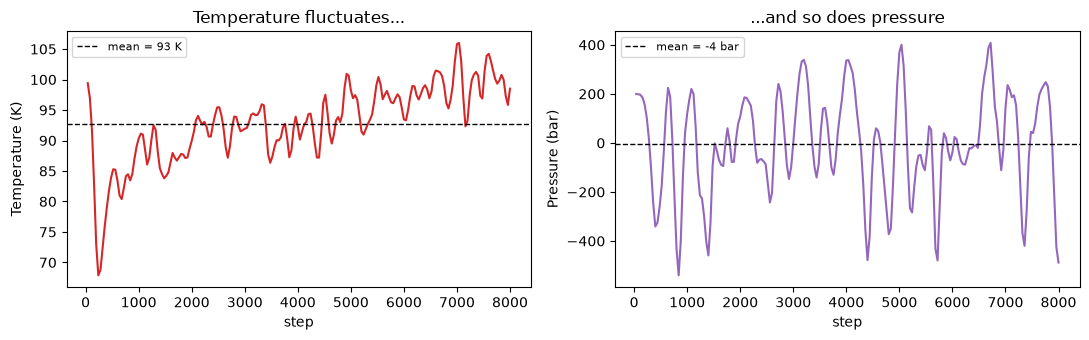

Even though the TOTAL ENERGY was constant (Section 5), temperature and pressure
both fluctuate freely -- in NVE, energy is fixed, but it constantly reshuffles
between kinetic and potential, which is exactly what makes T and P fluctuate.


In [14]:
# Track T and P alongside KE/PE over the SAME NVE trajectory we already ran data for
T_nve, P_nve = [], []
simulation_nve.context.setPositions(positions * unit.nanometer)  # restart from the same initial state...
simulation_nve.context.setVelocities(velocities * unit.nanometer / unit.picosecond)  # ...to record T, P this time

for i in range(N_STEPS_NVE // RECORD_EVERY):
    simulation_nve.step(RECORD_EVERY)
    state = simulation_nve.context.getState(getEnergy=True)
    T_nve.append(temperature_kelvin(state, ndof_system))
    P_nve.append(pressure_bar(simulation_nve))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(steps_nve, T_nve, color="tab:red")
axes[0].axhline(np.mean(T_nve), color="k", ls="--", lw=1, label=f"mean = {np.mean(T_nve):.0f} K")
axes[0].set_xlabel("step"); axes[0].set_ylabel("Temperature (K)"); axes[0].set_title("Temperature fluctuates...")
axes[0].legend(fontsize=8)

axes[1].plot(steps_nve, P_nve, color="tab:purple")
axes[1].axhline(np.mean(P_nve), color="k", ls="--", lw=1, label=f"mean = {np.mean(P_nve):.0f} bar")
axes[1].set_xlabel("step"); axes[1].set_ylabel("Pressure (bar)"); axes[1].set_title("...and so does pressure")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Even though the TOTAL ENERGY was constant (Section 5), temperature and pressure")
print("both fluctuate freely -- in NVE, energy is fixed, but it constantly reshuffles")
print("between kinetic and potential, which is exactly what makes T and P fluctuate.")



## 7. Simulating at constant temperature: thermostats

Most experiments (and the ethanol practical that follows this notebook) are not done at constant energy — they are done at constant **temperature**, with the system free to exchange energy with its surroundings (like a flask sitting in a water bath). Plain Newtonian dynamics (Section 5) conserves energy by construction and has no way to do this on its own; we need to add a **thermostat**.

OpenMM's `LangevinMiddleIntegrator` implements one of the most common thermostats, the **Langevin thermostat**. Physically, it models the surrounding heat bath as a source of two things acting on every particle at every step:

- a small **friction** force, proportional to the particle's velocity (drains excess kinetic energy — like drag);
- a small **random kick**, drawn from an appropriate Gaussian distribution (injects energy back in — like being randomly bumped by invisible solvent molecules).

Together, friction and random kicks balance out so that, on average, the system settles at the target temperature, with realistic thermal fluctuations around it — but, crucially, the **total energy of the particles alone is no longer conserved**, because energy is now flowing in and out through the (implicit) bath.


NVT run finished in 0.7 s


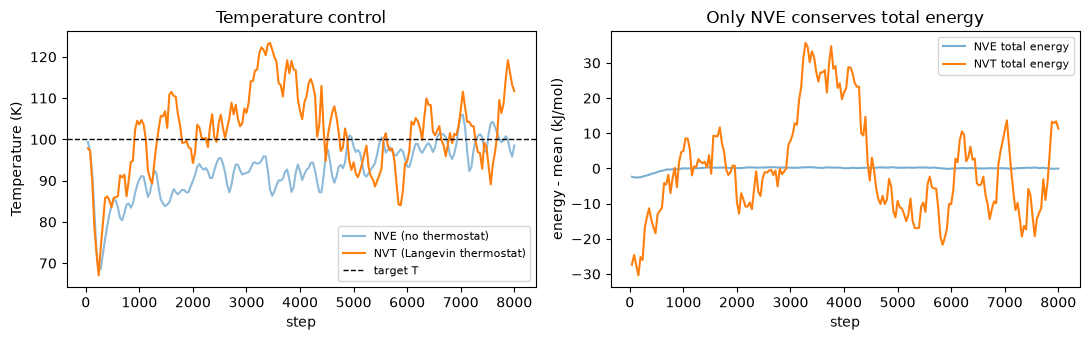

NVE: mean T = 92.8 K (drifts freely, no target)
NVT: mean T = 101.6 K (actively held near 100 K)


In [15]:
system_nvt = build_lj_system(topology, box_vectors)   # identical system, fresh System object
integrator_nvt = mm.LangevinMiddleIntegrator(TARGET_TEMPERATURE, 1 / unit.picosecond, 0.001 * unit.picoseconds)
simulation_nvt = app.Simulation(topology, system_nvt, integrator_nvt, platform, {"Threads": "4"})
simulation_nvt.context.setPositions(positions * unit.nanometer)
simulation_nvt.context.setVelocities(velocities * unit.nanometer / unit.picosecond)

steps_nvt, T_nvt, P_nvt, E_total_nvt = [], [], [], []
t0 = time.time()
for i in range(N_STEPS_NVE // RECORD_EVERY):
    simulation_nvt.step(RECORD_EVERY)
    state = simulation_nvt.context.getState(getEnergy=True)
    steps_nvt.append((i + 1) * RECORD_EVERY)
    T_nvt.append(temperature_kelvin(state, ndof_system))
    P_nvt.append(pressure_bar(simulation_nvt))
    E_total_nvt.append(state.getKineticEnergy().value_in_unit(unit.kilojoule_per_mole)
                        + state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole))
print(f"NVT run finished in {time.time() - t0:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(steps_nve, T_nve, alpha=0.5, label="NVE (no thermostat)")
axes[0].plot(steps_nvt, T_nvt, label="NVT (Langevin thermostat)")
axes[0].axhline(T_target_K, color="k", ls="--", lw=1, label="target T")
axes[0].set_xlabel("step"); axes[0].set_ylabel("Temperature (K)"); axes[0].set_title("Temperature control")
axes[0].legend(fontsize=8)

axes[1].plot(steps_nve, E_total_nve - E_total_nve.mean(), alpha=0.6, label="NVE total energy")
axes[1].plot(steps_nvt, np.array(E_total_nvt) - np.mean(E_total_nvt), label="NVT total energy")
axes[1].set_xlabel("step"); axes[1].set_ylabel("energy - mean (kJ/mol)")
axes[1].set_title("Only NVE conserves total energy")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"NVE: mean T = {np.mean(T_nve):.1f} K (drifts freely, no target)")
print(f"NVT: mean T = {np.mean(T_nvt):.1f} K (actively held near {T_target_K:.0f} K)")



Notice that under NVT the temperature stays centered on the target value throughout the run (instead of drifting wherever the initial condition happened to leave it, as in NVE), while the total energy of the particles now wanders — that wandering *is* the thermostat doing its job, letting energy flow in and out to keep the temperature fixed.

This is exactly the kind of integrator (`LangevinMiddleIntegrator`) we used for every stage of the ethanol simulation, and the same virial-pressure and equipartition-temperature formulas from Section 6 are what we used there too — just with more atoms, bonds, constraints, and (in the NPT stages) a barostat added on top of the thermostat.
